# Trabajo Práctico 1

## Parte 1 (imágenes en /white_patch):

1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White patch.

## Parte 2:
1. Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCVen escala de grisas y visualizarlas.
2. Elija el numerode binsque crea conveniente y grafique su histograma, compare los histogramas entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

# $$ --- RESOLUCION --- $$

## Parte 1 (imágenes en /white_patch):

In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

### Implementación de White Patch

White Patch supone que en la escena existe algún punto que debería ser blanco. Para cada canal de color, se estima la iluminación como el valor máximo observado y se escala el canal para que ese valor llegue a 255.

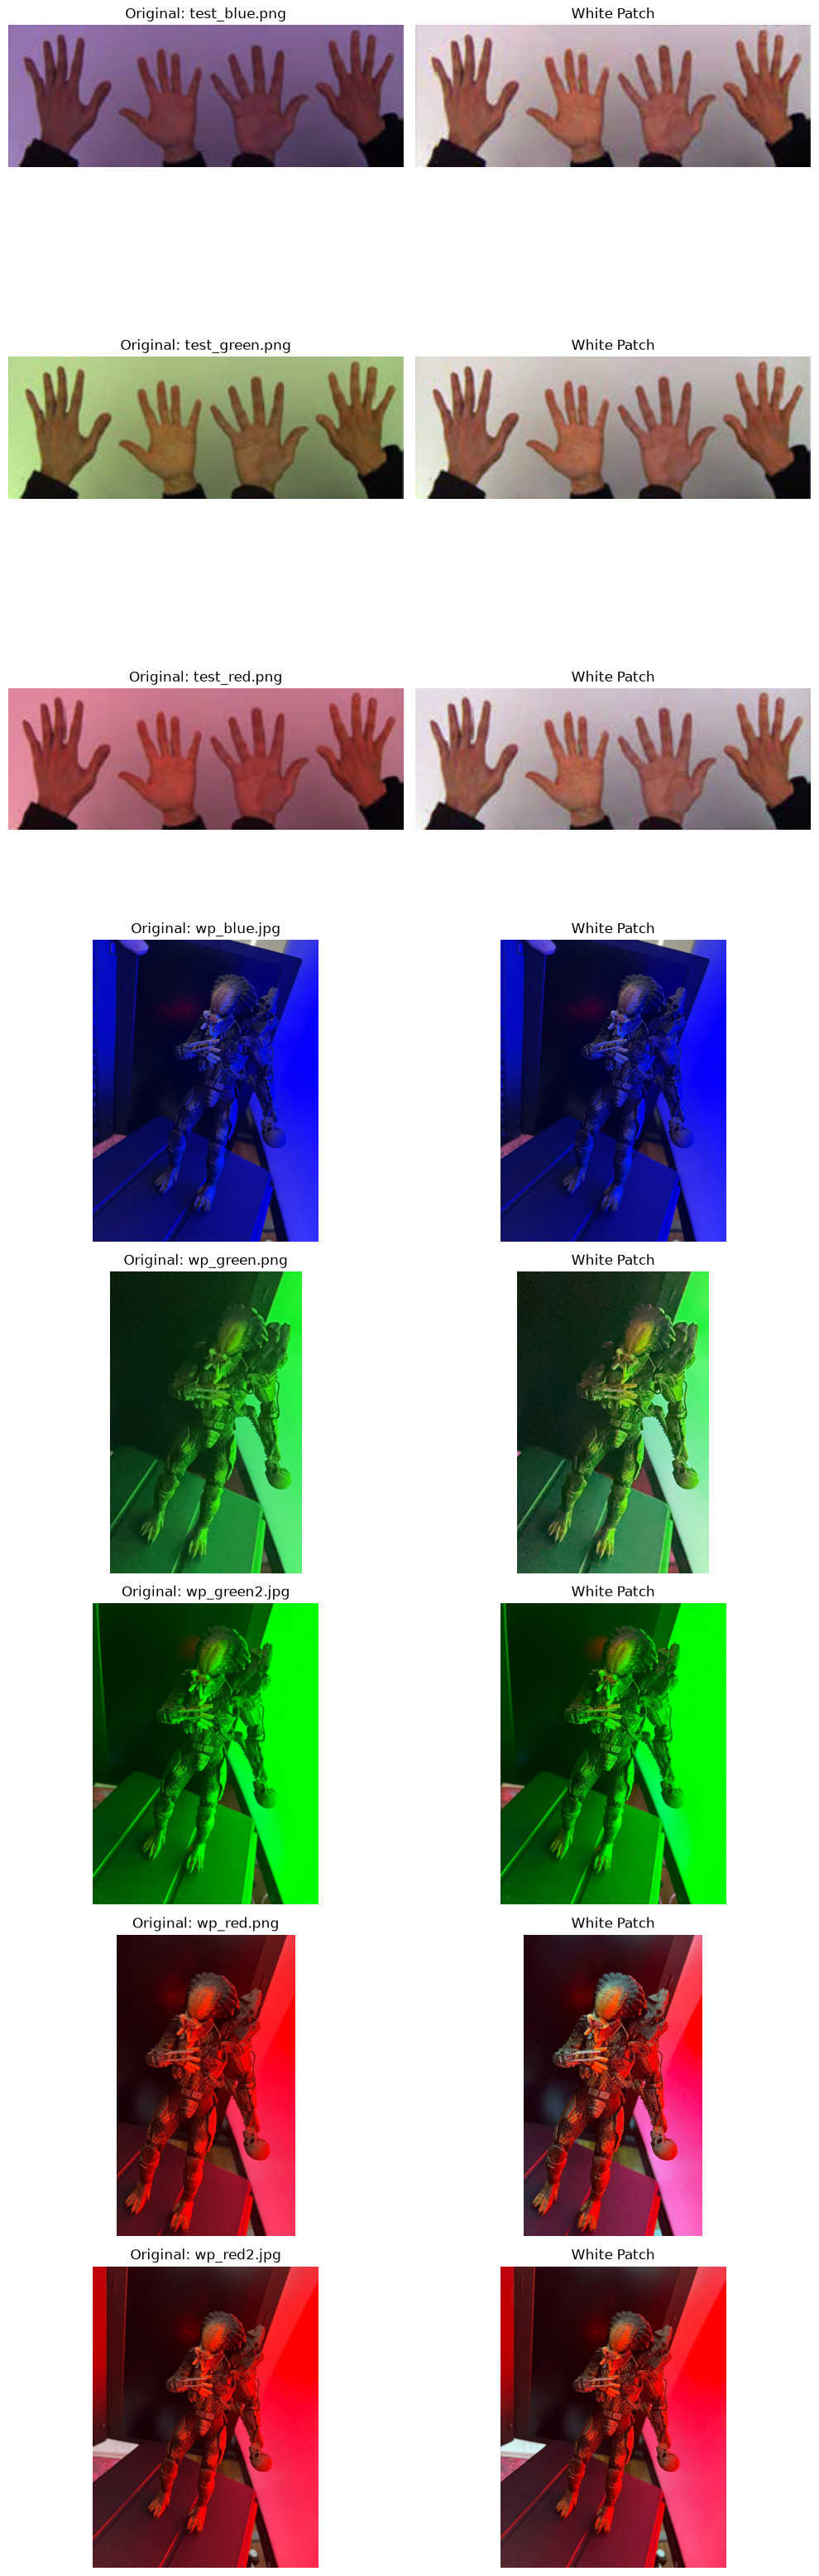

In [4]:
from pathlib import Path

def white_patch(image_bgr, percentile=100):
    """Corrige el color suponiendo que el punto más claro debe ser blanco."""
    image = image_bgr.astype(np.float32)
    channel_reference = np.percentile(image, percentile, axis=(0, 1))
    channel_reference = np.maximum(channel_reference, 1.0)
    corrected = image * (255.0 / channel_reference)
    return np.clip(corrected, 0, 255).astype(np.uint8)

image_paths = sorted(Path("white_patch").glob("*"))
fig, axes = plt.subplots(len(image_paths), 2, figsize=(10, 4 * len(image_paths)))
if len(image_paths) == 1:
    axes = np.array([axes])

for row, image_path in enumerate(image_paths):
    image_bgr = cv.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"No se pudo leer {image_path}")

    corrected_bgr = white_patch(image_bgr)
    original_rgb = cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB)
    corrected_rgb = cv.cvtColor(corrected_bgr, cv.COLOR_BGR2RGB)

    axes[row, 0].imshow(original_rgb)
    axes[row, 0].set_title(f"Original: {image_path.name}")
    axes[row, 1].imshow(corrected_rgb)
    axes[row, 1].set_title("White Patch")
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

Como se puede observar en el plot, en las fotos de las manos la corrección neutraliza bastante bien las dominantes azul, verde y roja. Pero en las imágenes del depredador se ve una mejora muy limitada. Esto se debe a que la iluminación coloreada es muy intensa y no necesariamente existe un objeto blanco confiable. Se puede utilizar `percentile=99` para mejorar estas imágenes, como se ve a continuación:

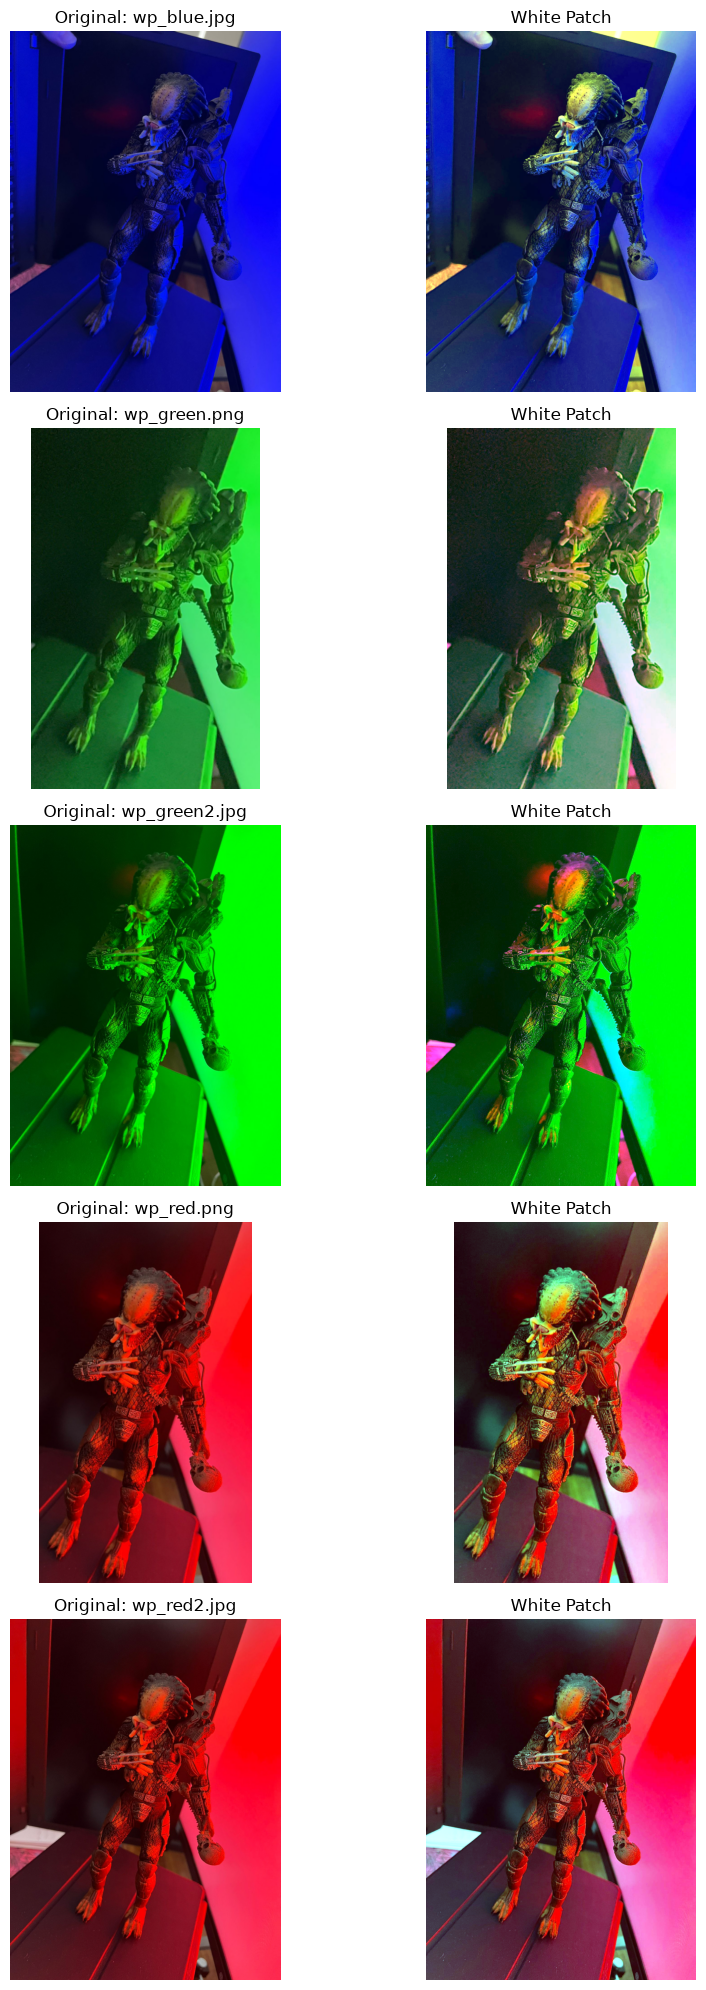

In [6]:
image_paths = sorted(Path("white_patch").glob("wp*"))
fig, axes = plt.subplots(len(image_paths), 2, figsize=(10, 4 * len(image_paths)))
if len(image_paths) == 1:
    axes = np.array([axes])

for row, image_path in enumerate(image_paths):
    image_bgr = cv.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"No se pudo leer {image_path}")

    corrected_bgr = white_patch(image_bgr, percentile=99)
    original_rgb = cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB)
    corrected_rgb = cv.cvtColor(corrected_bgr, cv.COLOR_BGR2RGB)

    axes[row, 0].imshow(original_rgb)
    axes[row, 0].set_title(f"Original: {image_path.name}")
    axes[row, 1].imshow(corrected_rgb)
    axes[row, 1].set_title("White Patch")
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

Cuando se usa `percentile=100` se usa el máximo absoluto, lo cual puede ser problemático si unos pocos píxeles están saturados o contienen reflejos. Esos píxeles hacen que el factor de corrección sea demasiado pequeño y el resto de la imagen quede con poco contraste o con una dominante de color. Este enfoque clásico de White Patch funciona bien si existe una región blanca o gris neutra, como en las imágenes de las manos.
Con `percentile=99` en cada canal de color, se usa como referencia el valor que deja por debajo al 99% de los píxeles, y se ignoran aproximadamente el 1% más brillante. La mayoría de la imagen se corrige usando una referencia más representativa.

## Parte 2

### 1. Lectura en escala de grises y visualización

Leemos `img1_tp.png` e `img2_tp.png` con OpenCV usando `cv.IMREAD_GRAYSCALE`, y las mostramos con matplotlib.

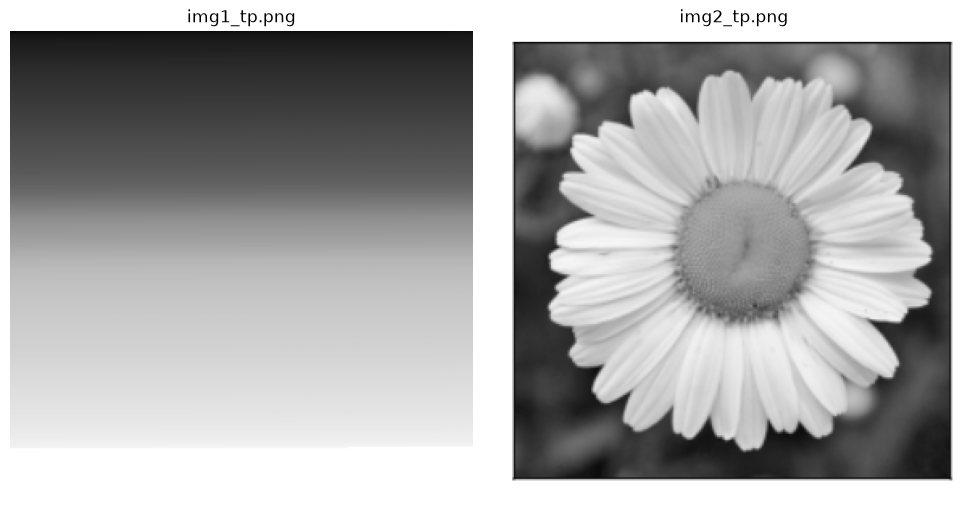

In [3]:
img1 = cv.imread("img1_tp.png", cv.IMREAD_GRAYSCALE)
img2 = cv.imread("img2_tp.png", cv.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise FileNotFoundError("No se pudieron leer img1_tp.png / img2_tp.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("img1_tp.png")
axes[0].axis("off")

axes[1].imshow(img2, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("img2_tp.png")
axes[1].axis("off")

plt.tight_layout()
plt.show()


### 2. Histogramas

Elegimos **32 bins**, en lugar de los 256 niveles de intensidad disponibles con 8 bits de profundidad. Esta decisión responde a un compromiso entre resolución y legibilidad: graficar los 256 niveles individuales expone cada variación de intensidad pixel a pixel, generando un histograma con ruido de alta frecuencia que dificulta ver la forma general de la distribución. Al agrupar los niveles en 32 bins (cada uno agregando 8 niveles consecutivos), el histograma actúa como una versión suavizada de la distribución de intensidades, lo que nos permitirá comparar la estructura tonal de ambas imágenes.

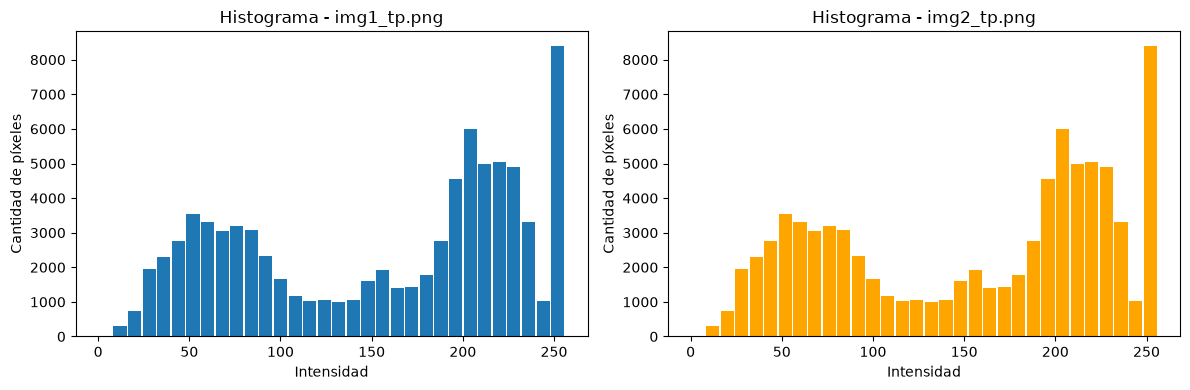

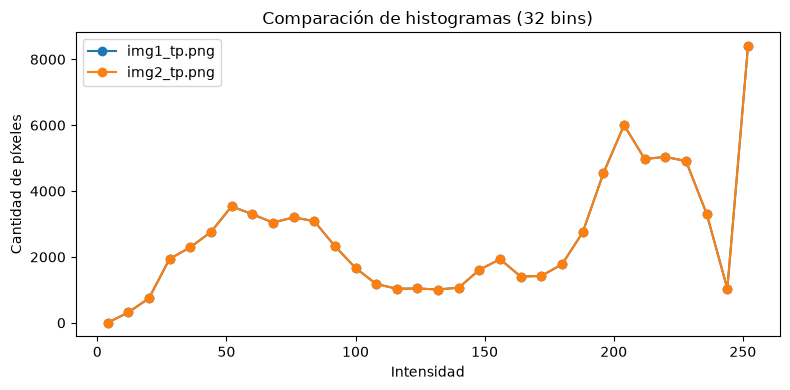

In [4]:
n_bins = 32

hist1 = cv.calcHist([img1], [0], None, [n_bins], [0, 256]).flatten()
hist2 = cv.calcHist([img2], [0], None, [n_bins], [0, 256]).flatten()

bin_edges = np.linspace(0, 256, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(bin_centers, hist1, width=(256 / n_bins) * 0.9)
axes[0].set_title("Histograma - img1_tp.png")
axes[0].set_xlabel("Intensidad")
axes[0].set_ylabel("Cantidad de píxeles")

axes[1].bar(bin_centers, hist2, width=(256 / n_bins) * 0.9, color="orange")
axes[1].set_title("Histograma - img2_tp.png")
axes[1].set_xlabel("Intensidad")
axes[1].set_ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

# Superpuestos, para comparar directamente
plt.figure(figsize=(8, 4))
plt.plot(bin_centers, hist1, label="img1_tp.png", marker="o")
plt.plot(bin_centers, hist2, label="img2_tp.png", marker="o")
plt.xlabel("Intensidad")
plt.ylabel("Cantidad de píxeles")
plt.title("Comparación de histogramas (32 bins)")
plt.legend()
plt.tight_layout()
plt.show()


### Comparación y análisis

**Lo que se observa:**

El resultado más llamativo es que, al comparar los histogramas de `img1_tp.png` (el degradado de negro a blanco) e `img2_tp.png` (la foto de la flor), **ambos histogramas son exactamente iguales**, bin por bin. Sin embargo, las imágenes son completamente diferentes en su contenido visual: una es un gradiente sin ninguna estructura espacial y la otra tiene un objeto (la flor) claramente diferenciado del fondo.

Validamos que el **histograma es una función de las intensidades de los píxeles que descarta por completo la información espacial** (en qué posición `(u,v)` está cada valor de intensidad). Dos imágenes pueden tener la misma distribución de valores de gris -la misma "cantidad" de píxeles oscuros, medios y claros- pero estar organizadas espacialmente de manera totalmente distinta. En este caso, `img2_tp` parece ser una re-distribución espacial (por ejemplo, un reordenamiento de píxeles o una transformación que preserva el histograma) de los mismos niveles de intensidad que `img1_tp`, pero acomodados formando la imagen de la flor en lugar del degradado.

**¿Sirven los histogramas como *features* para clasificación o detección?**
El histograma por sí solo **no es un feature confiable** para un problema general de clasificación o detección de imágenes. Sin embargo, **puede considerarse como feature complementaria**. El histograma puede ser útil para resumir la información global de intensidad, pero no es suficiente por sí solo para distinguir imágenes con contenido semántico diferente.

- **Ventajas:**
  - Es un descriptor muy compacto: resume la distribución global de intensidades con pocos valores (por ejemplo, 32 bins) en lugar de conservar todos los píxeles.
  - Es **invariante a la posición** de los objetos dentro de la imagen, ya que no depende del orden espacial de los píxeles.
  - Puede ser útil en problemas acotados donde la diferencia relevante está en la distribución global de tonos, por ejemplo, imágenes muy oscuras frente a imágenes muy claras, o análisis de brillo y contraste.

- **Limitaciones:**
  - El histograma ignora la ubicación de cada intensidad dentro de la imagen; por ello, dos imágenes con contenido completamente distinto pueden tener el mismo histograma.
  - En este caso, el degradado y la flor tienen la misma distribución de tonos, pero una no puede diferenciarse de la otra si solo se usa el histograma como representación.
  - Es sensible a cambios de brillo y contraste; por lo tanto, la misma escena bajo distinta iluminación puede generar histogramas muy diferentes.
  - No captura textura, bordes, formas ni relaciones entre píxeles vecinos, por lo que no representa la estructura visual de la imagen.

**Conclusión:**  
El histograma es una herramienta útil para resumir información global de intensidad, pero no constituye una feature robusta para clasificación o detección general de imágenes. En la práctica, debe combinarse con descriptores espaciales o locales, como bordes, texturas, características de forma o representaciones aprendidas, para obtener una descripción realmente discriminativa.